In [20]:
import os
import pandas as pd
import numpy as np

In [19]:
import os
import pandas as pd
import numpy as np

# Define seed lists for different model configurations
seeds_somo_uc3d = [587, 590, 591]
seeds_esa_era_uc3d = [537, 538]

# Define base directory path for model results
fold = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/"
seeds_list = [seeds_somo_uc3d, seeds_esa_era_uc3d]

# Initialize list to store results
reslist = []

# Process SoMo-UC3D model results
for k in seeds_somo_uc3d:
    folder_path = fold + str(k)
    f = folder_path + "/"
    # Read R² spatial results CSV file
    r2_df = pd.read_csv(f + "r2_spatial.csv")
    # Extract R² values column
    reslist.append(r2_df["r2"])

# Combine results from all seeds into single DataFrame
reslist = reslist
res_df = pd.concat(reslist, axis=1)
# Add latitude and longitude coordinates from original data
res_df["lat"] = r2_df["lat"]
res_df["lon"] = r2_df["lon"]
# Calculate mean R² across all seed runs
res_df["mean"] = np.mean(res_df.iloc[:, :-2], axis=1)
res_somo_uc3d = res_df
# Save processed results to CSV file
res_somo_uc3d.to_csv('res_somo_uc3d.csv')

# Process ESA-ERA-UC3D model results
seeds_esa_era_uc3d = [537, 538]
fold = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/"
reslist = []
for k in seeds_esa_era_uc3d:
    folder_path = fold + str(k)
    f = folder_path + "/"
    # Read R² spatial results CSV file
    r2_df = pd.read_csv(f + "r2_spatial.csv")
    # Extract R² values column
    reslist.append(r2_df["r2"])

# Combine results from all seeds into single DataFrame
reslist = reslist
res_df = pd.concat(reslist, axis=1)
# Add latitude and longitude coordinates from original data
res_df["lat"] = r2_df["lat"]
res_df["lon"] = r2_df["lon"]
# Calculate mean R² across all seed runs
res_df["mean"] = np.mean(res_df.iloc[:, :-2], axis=1)
res_esa_era_uc3d = res_df
# Save processed results to CSV file
res_esa_era_uc3d.to_csv('res_esa_era_uc3d.csv')

In [21]:
import numpy as np
import ultraplot as uplt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes
from affine import Affine
from rasterio.features import rasterize
import xarray as xr
import cartopy.feature as cfeature
from numpy import ma 
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D
import rioxarray

# Define geographical boundaries for the study area
lonlim = (-82, -32)
latlim = (-60, 15)

# Configure plotting style using ultraplot
uplt.rc.style = 'seaborn-v0_8-paper'
# Update plot settings: tick length, direction, and font sizes
uplt.rc.update({
    'tick.len': 2.0,      # Set tick length
    'tick.dir': 'in',     # Set tick direction to inward
    'font.largesize': 12, # Set large font size
    'font.smallsize': 10  # Set small font size
})

In [22]:
# Load processed R² results from CSV files
res_esa_era_uc3d = pd.read_csv('res_esa_era_uc3d.csv')
res_somo_uc3d = pd.read_csv('res_somo_uc3d.csv')

# Convert ESA-ERA-UC3D results to 2D spatial format using pivot table
df_esa = res_esa_era_uc3d.pivot_table(index='lat', columns='lon', values='mean')
# Create xarray DataArray for ESA-ERA-UC3D with proper coordinates and dimensions
da_esa = xr.DataArray(df_esa, dims=('lat', 'lon'), coords={'lat': df_esa.index, 'lon': df_esa.columns})

# Convert SoMo-UC3D results to 2D spatial format using pivot table
df_somo = res_somo_uc3d.pivot_table(index='lat', columns='lon', values='mean')
# Create xarray DataArray for SoMo-UC3D with proper coordinates and dimensions
da_somo = xr.DataArray(df_somo, dims=('lat', 'lon'), coords={'lat': df_somo.index, 'lon': df_somo.columns})

In [26]:
# Load Amazon shapefile for geographical region masking
amazon_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/amazonia_polygons.shp"
# Read Amazon shapefile into GeoDataFrame
amazon_vector = gpd.read_file(amazon_shapefile)
# Dissolve all polygons into a single multi-polygon geometry
amazon_vector = amazon_vector.dissolve()
# Extract the first (and only) geometry as Amazon border
amazon_border = amazon_vector.loc[[0]]

# Load general geography regions shapefile for background mapping
geography_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/ne_10m_geography_regions_polys.shp"
# Read geography regions shapefile into GeoDataFrame
geography_vector = gpd.read_file(geography_shapefile)

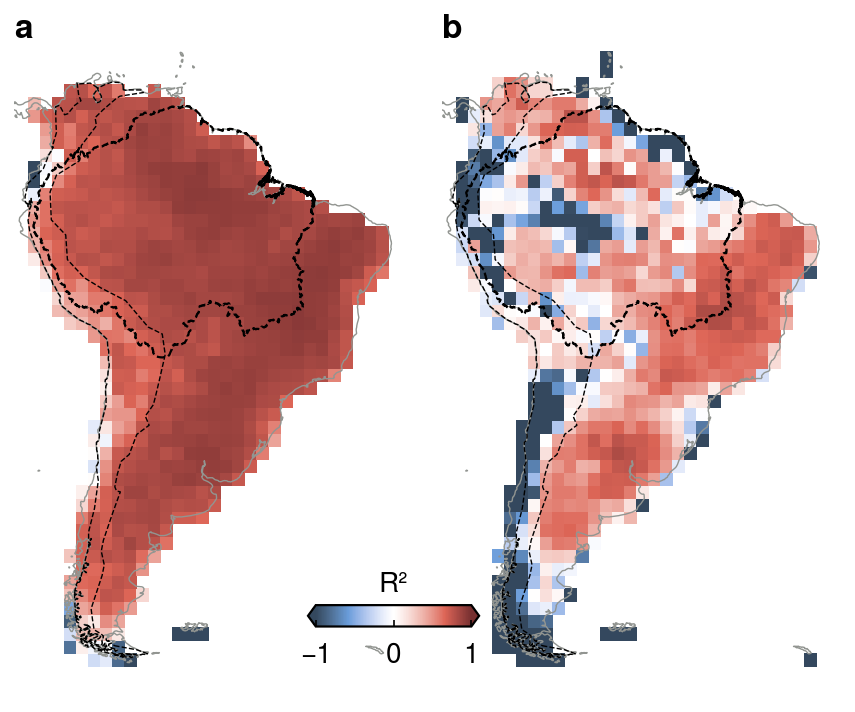

In [28]:
# Define map projection (using PlateCarree for simple lat/lon coordinates)
proj = ccrs.PlateCarree()

# Define subplot arrangement: 1 row with 2 columns
arrray = [[1, 2]]  # Subplot arrangement matrix

# Create figure with specified width and layout settings
fig = uplt.figure(refwidth=2, share=False, span=False, tight=True)
# Create subplots with specified projection and arrangement
axs = fig.subplots(arrray, projection=proj, abc=True, width_ratios=[1, 1], height_ratios=[1])
# Format subplots with geographical boundaries and remove frame lines
axs.format(lonlim=lonlim, latlim=latlim, linewidth=0)

# Plot first subplot: SoMo-UC3D results
ax = axs[0]
# Create colored mesh plot for R² values
im = ax.pcolormesh(
    da_somo.lon,           # Longitude coordinates
    da_somo.lat,           # Latitude coordinates  
    da_somo.values,        # R² values data
    cmap='negpos',         # Colormap for positive/negative values
    discrete=False,        # Continuous color scale
    transform=ccrs.PlateCarree(),  # Coordinate transformation
    vmin=-1, vmax=1,       # Color scale limits
)

# Add Amazon border as dashed line
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
# Add Andes mountain range border
geography_vector[geography_vector['NAME']=='ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
# Add coastline feature
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

# Plot second subplot: ESA-ERA-UC3D results
ax = axs[1]
# Create colored mesh plot for R² values
im = ax.pcolormesh(
    da_esa.lon,            # Longitude coordinates
    da_esa.lat,            # Latitude coordinates
    da_esa.values,         # R² values data
    cmap='negpos',         # Colormap for positive/negative values
    discrete=False,        # Continuous color scale
    transform=ccrs.PlateCarree(),  # Coordinate transformation
    vmin=-1, vmax=1,       # Color scale limits
)

# Add Amazon border as dashed line
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
# Add Andes mountain range border
geography_vector[geography_vector['NAME']=='ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')

# Create colorbar axis at specified position
cax = fig.add_axes([0.36, 0.12, 0.2, 0.03], title='R²', titlesize=10)
# Add colorbar to figure
fig.colorbar(
    im,                    # Image to create colorbar for
    cax=cax,               # Colorbar axis
    orientation='horizontal',  # Horizontal orientation
    extend='both',         # Extend arrows for out-of-range values
    ticks=[-1, 0, 1],      # Specific tick positions
)
# Add coastline feature to second subplot
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

In [29]:
res_somo_uc3d.mean()

Unnamed: 0    366.000000
r2              0.750234
r2.1            0.751199
r2.2            0.631844
lat           -16.475443
lon           -61.395634
mean            0.711092
dtype: float64